# 01 — Dataset Anatomy (THINGS-EEG)

Basic EDA to understand the structure and content of the preprocessed EEG data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths (works when run from notebooks/EDA/ or repo root)
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else (Path.cwd() / ".." / "..").resolve()
DATA_DIR = ROOT / "data" / "sub-01"
ARTIFACTS_DIR = ROOT / "artifacts" / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def load_preprocessed(path):
    """Load preprocessed EEG .npy file. Returns (data, ch_names, times)."""
    d = np.load(path, allow_pickle=True).item()
    return d["preprocessed_eeg_data"], d["ch_names"], d["times"]

X_train, ch_names, times = load_preprocessed(DATA_DIR / "preprocessed_eeg_training.npy")
X_test, ch_names_te, times_te = load_preprocessed(DATA_DIR / "preprocessed_eeg_test.npy")

## Shapes & axis meanings

**Expected axes:** `[participants, conditions, repetitions, channels, timepoints]`

In [3]:
print("TRAIN shape:", X_train.shape)
print("TEST  shape:", X_test.shape)
print("Channels:", len(ch_names), "→", ch_names)
print("Time grid: %.3f to %.3f s, %d points" % (float(times[0]), float(times[-1]), len(times)))

assert ch_names == ch_names_te, "Channel lists differ between train/test."
assert np.allclose(times, times_te), "Time grids differ between train/test."

# Handle 4D (single participant) vs 5D (multiple participants)
ndim = X_train.ndim
if ndim == 5:
    n_part, n_cond_tr, n_rep_tr, n_ch, n_time = X_train.shape
    _, n_cond_te, n_rep_te, _, _ = X_test.shape
    print("\nAxes: [participants=%d, conditions=%d, repetitions=%d, channels=%d, timepoints=%d]" 
          % (n_part, n_cond_tr, n_rep_tr, n_ch, n_time))
else:
    n_cond_tr, n_rep_tr, n_ch, n_time = X_train.shape
    _, n_rep_te, _, _ = X_test.shape
    n_part = 1
    print("\nAxes (4D, single participant): [conditions=%d, repetitions=%d, channels=%d, timepoints=%d]" 
          % (n_cond_tr, n_rep_tr, n_ch, n_time))

TRAIN shape: (16540, 4, 17, 100)
TEST  shape: (200, 80, 17, 100)
Channels: 17 → ['Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2']
Time grid: -0.200 to 0.790 s, 100 points

Axes (4D, single participant): [conditions=16540, repetitions=4, channels=17, timepoints=100]


## Basic statistics

Value ranges and distribution (training data, first participant).

In [4]:
# Use first participant if multiple
X0 = X_train[0] if X_train.ndim == 5 else X_train
print("min: %.4f  max: %.4f  mean: %.4f  std: %.4f" % (X0.min(), X0.max(), X0.mean(), X0.std()))
print("dtype:", X_train.dtype)

min: -328.7584  max: 85.1462  mean: -0.0350  std: 0.8401
dtype: float64


## Grand average ERP

Average over all conditions and repetitions. Should show stimulus-locked structure (e.g., P1/N1 around 100–200 ms).

In [5]:
# Grand average: mean over conditions and repetitions
# 5D: axis 1=conditions, 2=repetitions → [participants, channels, time]
# 4D: axis 0=conditions, 1=repetitions → [channels, time]; add leading dim for consistency
erp_train = X_train.mean(axis=(1, 2)) if X_train.ndim == 5 else X_train.mean(axis=(0, 1))[np.newaxis]
erp_test = X_test.mean(axis=(1, 2)) if X_test.ndim == 5 else X_test.mean(axis=(0, 1))[np.newaxis]
print("ERP train shape:", erp_train.shape)
print("ERP test  shape:", erp_test.shape)

ERP train shape: (1, 17, 100)
ERP test  shape: (1, 17, 100)


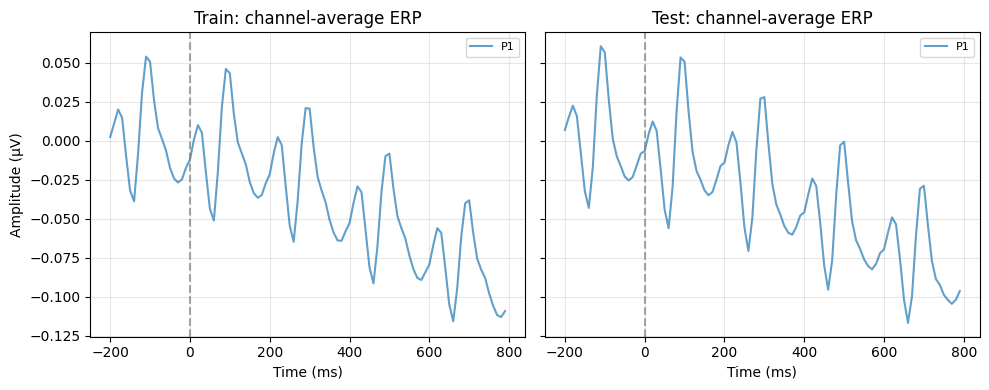

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Channel-average ERP (average across all 17 channels)
for p in range(erp_train.shape[0]):
    ch_avg = erp_train[p].mean(axis=0)
    axes[0].plot(times * 1000, ch_avg, alpha=0.7, label=f"P{p+1}" if erp_train.shape[0] <= 5 else None)
if erp_train.shape[0] > 5:
    axes[0].plot(times * 1000, erp_train.mean(axis=(0, 1)), "k-", lw=2, label="mean")
axes[0].axvline(0, color="gray", ls="--", alpha=0.7)
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].set_title("Train: channel-average ERP")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.3)

for p in range(erp_test.shape[0]):
    ch_avg = erp_test[p].mean(axis=0)
    axes[1].plot(times * 1000, ch_avg, alpha=0.7, label=f"P{p+1}" if erp_test.shape[0] <= 5 else None)
if erp_test.shape[0] > 5:
    axes[1].plot(times * 1000, erp_test.mean(axis=(0, 1)), "k-", lw=2, label="mean")
axes[1].axvline(0, color="gray", ls="--", alpha=0.7)
axes[1].set_xlabel("Time (ms)")
axes[1].set_title("Test: channel-average ERP")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda__grand_average_erp__2026-02-25.png", dpi=200, bbox_inches="tight")
plt.show()

## Per-channel ERP (first participant)

All 17 occipital/parietal channels. Early visual responses (P1/N1) typically appear ~100–200 ms post-stimulus.

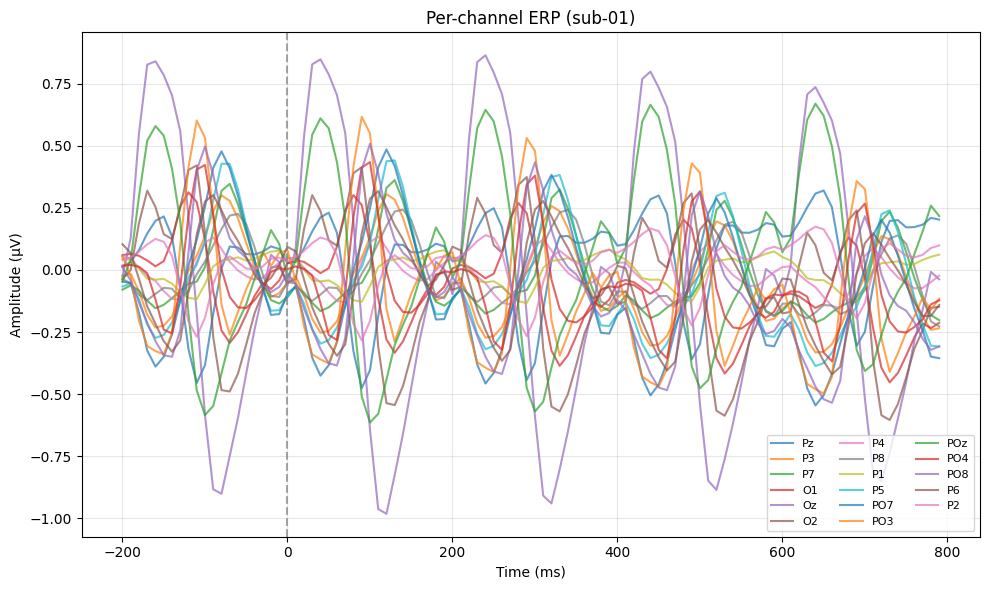

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
erp_p0 = erp_train[0]  # first participant
for i, ch in enumerate(ch_names):
    ax.plot(times * 1000, erp_p0[i], alpha=0.7, label=ch)
ax.axvline(0, color="gray", ls="--", alpha=0.7)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Per-channel ERP (sub-01)")
ax.legend(ncol=3, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda__per_channel_erp__2026-02-25.png", dpi=200, bbox_inches="tight")
plt.show()

## Single condition view

One training condition: 4 repetitions × 17 channels × 100 timepoints. One test condition: 80 repetitions.

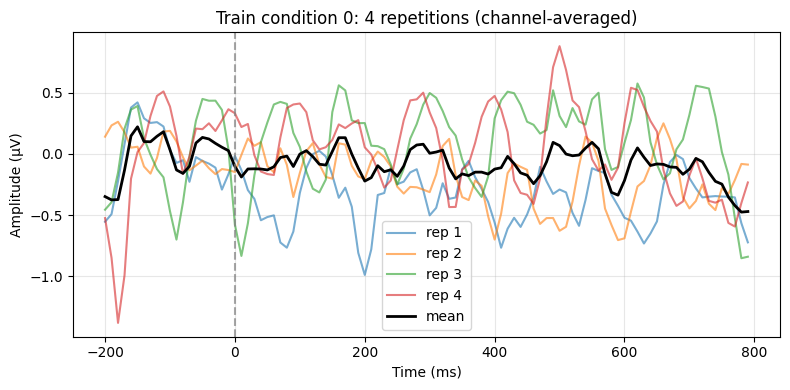

In [8]:
# Training: one condition, all 4 reps, channel-average
X0 = X_train[0] if X_train.ndim == 5 else X_train
cond0 = X0[0]  # first condition: [reps, channels, time]
ch_avg_trials = cond0.mean(axis=1)  # [reps, time]

fig, ax = plt.subplots(figsize=(8, 4))
for r in range(min(4, cond0.shape[0])):
    ax.plot(times * 1000, ch_avg_trials[r], alpha=0.6, label=f"rep {r+1}")
ax.plot(times * 1000, ch_avg_trials.mean(axis=0), "k-", lw=2, label="mean")
ax.axvline(0, color="gray", ls="--", alpha=0.7)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title("Train condition 0: 4 repetitions (channel-averaged)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda__single_condition_reps__2026-02-25.png", dpi=200, bbox_inches="tight")
plt.show()